<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/midterm/Instructions_mideterm2021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DSPS Midterm 2021

# Fitting models to GRB afterglow photometry

**This midterm is based on Blustin et al. 2005 https://arxiv.org/pdf/astro-ph/0507515.pdf.
All photometry is from the Swift satellite and it is obtained from Table 3**

Gamma-ray bursts (GRB) are the strongest and brightest explosions in the universe. They last mere seconds but produce as much energy as the sun does in its entire 10-billion-year life. 

The Gamma Ray energy is higly beamed (collimated into jets).
We do not know how they originate, although we think they may happen during the formation of black holes and we sometimes see them in conjunction with supernovae.
After a GRB flare, the source of the burst produces an afterglow in less-energetic wavelengths.


This exam models GRBs optical afterglows with simple models with different methods. 

The GRB afterglow is generated by a powerlaw process. A line is a power law in log-log space. You are asked to fit a power law to the GRB afterglow. A broken powerlaw, or a power law whose index changes at some point, is a prefer model for the GRB afterglow which you will also fit to the data.

You are given data of brightness of a GRB seconds after explosion over time; the brightness is expressed in "magnitude" which is log(flux) - this is what astrophsyics use as a default.

**All steps labeled "661" are mandatory for the Grad students and extra credit for the undergrads**

DATA INGESTION AND PROCESSING (5 points)
- 1 Read in the input dataset (1 point)
- 2 Visualize the data (2 points)
- 3 Create the log-time variable (1 point)
- 4 Plot the data in log space(1 point)

DATA MODELING (10 points for 461; 17 points for 661)
- 5 661 choose step 5 or 6: Solve using the Normal Equation (2 points)
- 6 661  choose step 5 or 6: Fit a line with a prepackaged function (2 points)
- 7 Fit a line to the data by minimizing an objective function (3 points)
- 8 Plot all the solutions (2 points)
- 9 Create a table with the results of each method (1 point)
- 10 Now try MCMC: fit a line with MCMC using emcee (3 points).
- 11 661 Now fit the correct model which is a "broken power law" (3 points)
- 12 Plot the data with the MCMC solution(s) on top (1 point). 

EXTRA CREDIT
Model selection (3 points)

On canvas the score is up to 100 points:

- 461 are scored based on 15 points max : 15 is normalized to 100, i.e. each point is 6.7/100th. 
- 661 students are scored based on 20 points. each point is 5/100th
- extra credit give you points up to the max (15 for 461 and 20 for 661) meaning if you lost points in mandatory tasks EC can compensate for them

#0  initial imports

In [ ]:
!pip install emcee

In [ ]:
!pip install corner

In [ ]:
import pandas as pd
import pylab as pl
import emcee
import corner

%pylab inline


Populating the interactive namespace from numpy and matplotlib


#1 Read in the input dataset (1 point)
You can use Pandas to read the csv file found here 
https://github.com/fedhere/DSPS_FBianco/tree/master/midterm

In [ ]:
grbAG = [...]
grbAG.head()

,filter,time,mag,magerr,upperlimit
0,V,66,13.21,0.24,0
1,V,67,12.90,0.23,0
2,V,68,12.86,0.23,0
3,V,69,13.01,0.23,0
4,V,70,12.97,0.23,0


In [ ]:
grbAG.tail()

,filter,time,mag,magerr,upperlimit
114,W1,63738,NaN,21.20,1
115,M2,74798,NaN,21.59,1
116,U,128928,NaN,20.05,1
117,V,971360,NaN,22.09,1
118,V,1171176,NaN,21.16,1


# 2 Visualize the data (2 points)

Note: The data are photometric measurements: measurement of flux from an exploding star with Gamma Ray emission. The flux is measured in different photometric bands, i.e. within different wavelength range. You can think about this as a filter that would limit the light collected by a camera to a single color, e.g. red, blue, or green. In most all cameras (your phone camera for example) collect data in RGB bands saparately and combine them to create a "color picture". Our eyes also perceive color in 3 bands, R, G, B. The information about the photometric band that collected each data point for this GRB is stored in the variable ```grbAG.filter```. 

TASK: 
- Plot the data points and the errorbars. Plot the data points with different colors for different "filters". _The filters are optical bands so they represent flux at different wavelengths. After plotting them in different colors you will treat them all the same for the purpose of this exam_.
Plot the upperlimit in a way that clearly identifies them as being different from the other points.

- **661:** Write the code that plots the data **as a function** that you will reuse it later. While this is optional for 461 students it is convenient to have the function since you will replot the data multiple times.


#3 Create the log-time variable (1 point)

Note: The emission is generated by a power-law generative process. To model it we will move to log space -log10(x)- and model it as a line there like we did in the class. _You will fit a line in log space. That corresponds to fitting a powerlaw $y=x^a$ in natural space._ 


TASK: 
- Crete a new dataframe column that contains the log10 of the time axis

- Replot the data using the same function as you did before.


#4 Plot the data in log space(1 point)
 
The brightness was given to you in log space already, but the time was not. To fit a line to a power law we need to move to log-log space, so we also need to take the log of the exogenous (_x_) variable.

TASK: 
- This time do not plot the upperlimits. Since you will not use them hereafter you can remove them from the dataset (e.g. create a view of your dataframe that does not have the upperlimits at this point)

- Plot the data with different colors for different photometric bands using the same function you used before (661: how do you write a function that allows you to choose which column of the dataframe to use for the x axis?).

(dont forget to explain what you see in the caption)

In [ ]:
plotit(grbAG, x="logtime")

Figure 2: ...


#5 661 - choose step 5 or 6: Solve using the Normal Equation (2 points)

_From here onwards your exogenous (x) variable is lottime_

It can be shown that the best linear fit to data is given by the equation:  

$(X^T \cdot X)^{-1} \cdot X^T \cdot \vec{y}$

The solution is a tuple of 2 parameters: sloper and intercept. Therefore the input has to be Nx2

TASK: 
- Fit the line function to the data (after removing the upper limits) like you did in the homework 


In [ ]:
theta_best = ...
print ("best fit parameters from the Normal Equation: " + 
       "intercept {:.2f}, slope {:.2f}".format(*theta_best))

# 6 661 choose step 5 or 6: Fit a line with a prepackaged function (2 points)
 _From here onwards your exogenous (x) variable is logtime_
 
 TASK: 
 - Fit a line to the logdata (excluding the upper limits) with a prepackaged function. You can choose to use sklearn LinearRegression (preferred), scipy linefit, or some other prepackaged function




In [ ]:
#note: imports should be moved to the top cell - follow PEP8 guidelines
from sklearn.linear_model import LinearRegression #or some other functions)
...
print ("best fit parameters from the sklearn LinearRegression(): " + 
       "intercept {:.2f}, slope {:.2f}".format(lr.intercept_, lr.coef_[1]))


# 7 Fit a line to the data by minimizing an objective function (3 points)


TASK:
- First, write an objective (or loss) function and justify which function you used. 
- Then use ```scipy.optimize.minimize()``` to minimize it.




In [ ]:
#note: imports should be moved to the top cell - follow PEP8 guidelines
from scipy.optimize import minimize

def line(theta, x):
    
def loss(....
print("best fit parameters from the minimization of ...)

# 8 Plot all the solutions (2 points)

TASK: 
- Create a function that uses the parameters you input and plots a line. 
- Replot the data using your original function and in the same plot add a line for each solution you generated. 
- Add a legend that describes which line corresponds to which model.


In [ ]:
#it might be useful to define a function that plots the line, tho it is not required
def plotline(...):
...

Figure 3: ...

# 9 Create a table with the results of each method (1 point)
(see here for table syntax in markdown) https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet#tables


# 10 Now try MCMC: fit a line with MCMC using emcee (3 points).


Assume Gaussian error which simplify the shape of the likelihood (so essentially the functions are identical to what we wrote in class this past week and you can use the code in the demo as a template https://github.com/fedhere/DSPS_FBianco/blob/master/MCMC/DIYMCMC.ipynb.)

look at documentation: https://emcee.readthedocs.io/en/stable/

TASKS:
- define a function ```log_probability```, same as we did in class


- define a function ```log_prior```, same as we did in class. Justify your choice of prior in a text cell


- define a function ```log_likelihood```, same as we did in class

- run the MCMC with the emcee package (like we did in class) and plot the marginalized distribuiton of the slope and intercept parameters in a "corner" plot like we did in class

- plot the chains


In [ ]:
def log_prior(theta)...

In [ ]:
def log_likelihood(theta, x, y, yerr)...

In [ ]:
def log_probability(theta, x, y, yerr)...

In [ ]:
#initial guess (some suggestions are left in the code below, you can change them as you see fit)
ig = [1,10]
#initialize walkers
nwalkers = 32
ndim = len(ig)

In [ ]:
pos = ...
pos.shape

(32, 2)

In [ ]:
sampler = ...
samples = ...
samples.shape

100%|██████████| 5000/5000 [00:06<00:00, 743.74it/s]


(5000, 32, 2)

In [ ]:
flat_samples = ...
mcmc_line

array([[2.46612274, 2.4799348 , 2.4942973 ],
       [8.56033447, 8.60000125, 8.63879492]])

findfont: Font family ['["sans-serif"]'] not found. Falling back to DejaVu Sans.


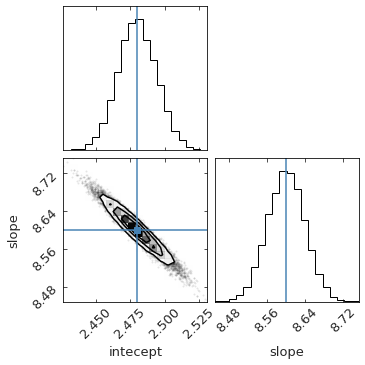

In [ ]:
#plot

In [ ]:
#plot the chais. what can you tell about the model success from them?

#12 661 Fit a more correct model: a "broken power law" (3 points)

The new model in natural (not-log) space is:

$F(t) = \frac{F_0}{ \frac{t}{T_b}^{-a1} + \frac{t}{T_b}^{-a2}}$

in log space this is:

$mag(t) = b - log_{10}((\frac{t}{T_b})^{-a1} + (\frac{t}{T_b})^{-a2}) $

$a1$ is the first slope, 

$a2$ is the slope after a break

$T_b$ is the locatin of said break (in time)

$b$ is equivalent to an intercept

Note that I wrote the model as a function of t, not log(t) and the log is taken inside the function. So your _x_ variable here should be time again, not logtime. 

The parameters to be optimized then are 4: b, a1, a2, $T_b$.

TASKS: 
- Write this function up (same way in which we wrote a function for the line) 
- Write the new log_likelihood, log_prior, and log_probability. 
- Fit the new model to the data with the emcee package. Assume Gaussian error which simplify the shape of the likelihood (to essentially the same likelihood that we used in the past). 
- Make a corner plot
- Plot the chains

What would you set as a prior? Justify your choice

In [ ]:
def log_prior(theta):...
def log_probability(theta, x, y, yerr):...
def log_likelihood_bpl(theta, x, y, yerr):...


#12 Plot the data with the MCMC solution(s) on top (1 point). 
TASK: 
- Plot the MCMC solutions, 1 i you only did point 10, 2 if you did point 11 as well. 
- If you have the broken power law solution also plot a vertical line indicating the position of the break T_b

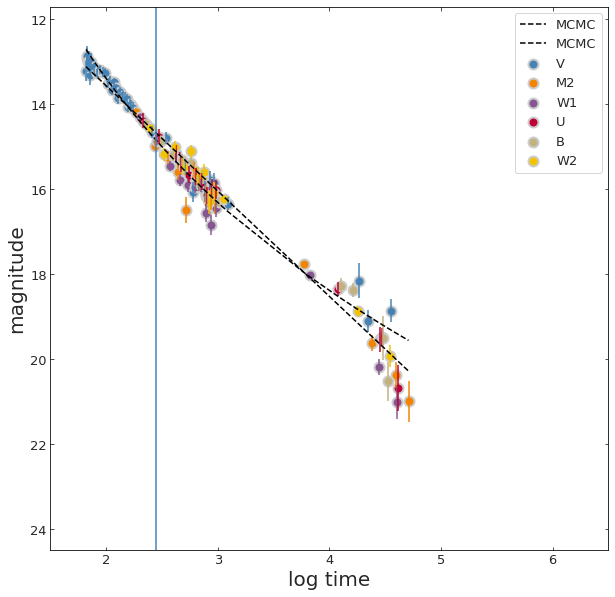

#Extra Credit for everyone: Model selection